# Training a Multiclass Classifier for Tropical Cyclones

We now have more data to train a harder task: multiclass classification according to the Saffir-Simpson scale for hurricane classification. This will look largely the same as the binary classification, with a few differences.

## Imports

Import everything we need. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from torchvision import models
import numpy as np
from tqdm import tqdm
import random
import os
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import math
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import sys
sys.path.append('../scripts')
from dataset import GOESDataset
from resnet_classifier import CycloneClassifier, split_dataset, get_device

retrain = False

## Create the Model and Trainer Classes

We need to create the model class. We'll just used pretrained ImageNet weights for a ResNet-18 model for something lightweight.

In [2]:
class CycloneCategoryTrainer:
    """Training pipeline for cyclone classifier."""
    
    def __init__(self, model, train_loader, val_loader, device, learning_rate=1e-3, log_file='training_log.csv', tensorboard_dir='runs'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.log_file = log_file
        
        # TensorBoard writer
        self.writer = SummaryWriter(tensorboard_dir)
        print(f"TensorBoard logging to: {tensorboard_dir}")
        print(f"Start TensorBoard with: tensorboard --logdir={tensorboard_dir}")
        
        # Label mapping
        self.label_map = {
            '-9999': 0, 
            'Tropical Storm or Below': 1,
            'Category 1': 2,
            'Category 2': 3,
            'Category 3': 4,
            'Category 4': 5,
            'Category 5': 6
        }

        # Loss and optimizer
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3
        )
        
        # Tracking
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.best_val_loss = float('inf')
        self.global_step = 0
        
        # Initialize log file
        with open(self.log_file, 'w') as f:
            f.write('epoch,train_loss,train_acc,val_loss,val_acc,learning_rate\n')

    def train_epoch(self):
        """Train for one epoch."""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc='Training')
        for batch_idx, batch in enumerate(pbar):
            images = batch['patch'].to(self.device)
            # Convert string labels to integers
            labels = torch.tensor([self.label_map[cat] for cat in batch['label']]).to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Log to TensorBoard (every batch)
            self.writer.add_scalar('Loss/train_batch', loss.item(), self.global_step)
            self.writer.add_scalar('Accuracy/train_batch', 100. * predicted.eq(labels).sum().item() / labels.size(0), self.global_step)
            self.global_step += 1
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
        
        epoch_loss = running_loss / total
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def validate(self):
        """Validate the model."""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc='Validation')
            for batch in pbar:
                images = batch['patch'].to(self.device)

                # Set up labels according to prepared image metadata from observations
                labels = torch.tensor([self.label_map[cat] for cat in batch['label']]).to(self.device)

                # Forward pass
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                # Statistics
                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100.*correct/total:.2f}%'
                })
        
        epoch_loss = running_loss / total
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def train(self, num_epochs, save_path='best_model.pth'):
        """Full training loop."""
        print(f"Training on device: {self.device}")
        print(f"Training samples: {len(self.train_loader.dataset)}")
        print(f"Validation samples: {len(self.val_loader.dataset)}")
        print(f"Logging to: {self.log_file}")
        
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print("-" * 50)
            
            # Train
            train_loss, train_acc = self.train_epoch()
            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)
            
            # Validate
            val_loss, val_acc = self.validate()
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
            
            # Log epoch metrics to TensorBoard
            self.writer.add_scalar('Loss/train_epoch', train_loss, epoch)
            self.writer.add_scalar('Loss/val_epoch', val_loss, epoch)
            self.writer.add_scalar('Accuracy/train_epoch', train_acc, epoch)
            self.writer.add_scalar('Accuracy/val_epoch', val_acc, epoch)
            self.writer.add_scalar('Learning_Rate', current_lr, epoch)
            
            # Log to CSV file
            with open(self.log_file, 'a') as f:
                f.write(f'{epoch+1},{train_loss:.6f},{train_acc:.4f},{val_loss:.6f},{val_acc:.4f},{current_lr:.8f}\n')
            
            # Print epoch summary
            print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            print(f"Learning Rate: {current_lr:.8f}")
            
            # Save best model
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_loss': val_loss,
                    'val_acc': val_acc,
                }, save_path)
                print(f"✓ Saved best model (val_loss: {val_loss:.4f})")
        
        # Close TensorBoard writer
        self.writer.close()
        
        print("\n" + "="*50)
        print("Training complete!")
        print(f"Best validation loss: {self.best_val_loss:.4f}")
        
        return {
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accs': self.train_accs,
            'val_accs': self.val_accs
        }

In [3]:
# Set paths
metadata_path = '/Users/dylanwhite/Projects/tropical-cv/data/training/image_data_with_obs_data.json'
weights_dir = '/Users/dylanwhite/Projects/tropical-cv/weights/resnet_classifier'
tensorboard_dir = '/Users/dylanwhite/Projects/tropical-cv/runs/'

# Set parameters
seed = 42
use_three_channel = True
batch_size = 32
num_epochs = 50
learning_rate = 1e-3
patch_size = 512
num_workers = 2
val_split = 0.2

# Make output weights directory if it doesn't exist
os.makedirs(weights_dir,exist_ok=True)

# Setup device
device = get_device()
print(f"Using device: {device}")

# Create full dataset
full_dataset = GOESDataset(
    image_metadata_path=metadata_path,
    patch_size=patch_size,
    augment=True,
    center_bias=0.6,
    three_channel=use_three_channel,
    drop_missing=True,
    label_key='storm_category'
)

# Split into train and validation
train_dataset, val_dataset = split_dataset(
    full_dataset,
    val_split=val_split,
    seed=seed
)

# TODO: For validation, we want to disable augmentation
# Since we're using Subset, we need to handle this differently
# The augmentation will still be applied, but I could modify GOESDataset
# to accept an index list and handle augmentation per-sample if needed
# I think the better approach would be to just download a separate validation set

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False
)

# Create model
model = CycloneClassifier(
    num_classes=7, 
    pretrained=use_three_channel, 
    use_three_channel=use_three_channel
)

# Create trainer
if use_three_channel:
    weights_file = 'category_training_log_rgb.csv'
else:
    weights_file = 'category_training_log_grayscale.csv'
log_path = os.path.join(weights_dir,weights_file)
trainer = CycloneCategoryTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    learning_rate=learning_rate,
    log_file=log_path,
    tensorboard_dir=tensorboard_dir
)

# Train
if use_three_channel:
    weights_file = 'category_cyclone_classifier_rgb.pth'
else:
    weights_file = 'category_cyclone_classifier_grayscale.pth'
weights_path = os.path.join(weights_dir,weights_file)
if retrain:
    history = trainer.train(num_epochs=num_epochs, save_path=weights_path)
    print(f"\nTraining log saved to '{log_path}'")
    print(f"Best model saved to '{weights_path}'")
else:
    print('\nSkipping model training.')
    print(f"Previous training log saved to '{log_path}'")
    print(f"Previous best model saved to '{weights_path}'") 

Using device: mps
Dataset split (seed=42):
  Total samples: 944
  Training samples: 755
  Validation samples: 189


/Users/dylanwhite/Projects/tropical-cv/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/dylanwhite/Projects/tropical-cv/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


TensorBoard logging to: /Users/dylanwhite/Projects/tropical-cv/runs/
Start TensorBoard with: tensorboard --logdir=/Users/dylanwhite/Projects/tropical-cv/runs/

Skipping model training.
Previous training log saved to '/Users/dylanwhite/Projects/tropical-cv/weights/resnet_classifier/category_training_log_rgb.csv'
Previous best model saved to '/Users/dylanwhite/Projects/tropical-cv/weights/resnet_classifier/category_cyclone_classifier_rgb.pth'


In [11]:
# Updated label map
LABEL_MAP = {
    '-9999': 0, 
    'Tropical Storm or Below': 1,
    'Category 1': 2,
    'Category 2': 3,
    'Category 3': 4,
    'Category 4': 5,
    'Category 5': 6
}

# Reverse mapping for display
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}

def get_model_predictions(model, dataloader, device, label_map=LABEL_MAP):
    """
    Get all predictions and confidences from the model.
    
    Returns:
        predictions: list of dicts with 'patch', 'true_label', 'pred_label', 'confidence', 'pred_probs'
    """
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch['patch'].to(device)
            true_labels = torch.tensor([label_map[cat] for cat in batch['label']])
            
            # Get model predictions
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)  # Convert logits to probabilities
            confidences, pred_labels = probs.max(1)
            
            # Store results
            for i in range(images.size(0)):
                all_predictions.append({
                    'patch': batch['patch'][i].cpu(),
                    'true_label': true_labels[i].item(),
                    'pred_label': pred_labels[i].cpu().item(),
                    'confidence': confidences[i].cpu().item(),
                    'pred_probs': probs[i].cpu().numpy(),
                    'category_str': batch['label'][i]
                })
    
    return all_predictions


def filter_by_class(predictions, true_class=None, pred_class=None, correct_only=False, incorrect_only=False):
    """
    Filter predictions by true class, predicted class, or correctness.
    
    Args:
        predictions: list from get_model_predictions()
        true_class: int or None. Filter by true label (e.g., 0 for no storm, 6 for Cat 5)
        pred_class: int or None. Filter by predicted label
        correct_only: if True, only return correct predictions
        incorrect_only: if True, only return incorrect predictions
    
    Returns:
        filtered predictions sorted by confidence (descending)
    """
    filtered = []
    
    for pred in predictions:
        true_label = pred['true_label']
        pred_label = pred['pred_label']
        is_correct = (true_label == pred_label)
        
        # Apply filters
        if true_class is not None and true_label != true_class:
            continue
        if pred_class is not None and pred_label != pred_class:
            continue
        if correct_only and not is_correct:
            continue
        if incorrect_only and is_correct:
            continue
        
        filtered.append(pred)
    
    # Sort by confidence (descending)
    filtered.sort(key=lambda x: x['confidence'], reverse=True)
    
    return filtered

def visualize_predictions(predictions, num_images=16, title="Predictions"):
    """
    Create a mosaic visualization of predictions.
    
    Args:
        predictions: list of prediction dicts
        num_images: number of images to show
        title: title for the plot
    """
    if len(predictions) == 0:
        print(f"No predictions found for {title}")
        return
    
    # Limit to available predictions
    num_images = min(num_images, len(predictions))
    
    # Get patch size from first image
    patch_size = predictions[0]['patch'].shape[-1]
    
    # Calculate mosaic dimensions
    padding = 3
    mosaic_width = 4
    mosaic_height = math.ceil(num_images / mosaic_width)
    mosaic_img_width = mosaic_width * patch_size + (mosaic_width + 1) * padding
    mosaic_img_height = mosaic_height * patch_size + (mosaic_height + 1) * padding
    
    # Create empty mosaic array
    if predictions[0]['patch'].shape[0] == 3:  # RGB
        mosaic = np.zeros((mosaic_img_height, mosaic_img_width, 3), dtype=np.uint8)
    else:  # Grayscale
        mosaic = np.zeros((mosaic_img_height, mosaic_img_width), dtype=np.uint8)
    
    # Fill mosaic
    for idx in range(num_images):
        i = idx % mosaic_width
        j = idx // mosaic_width
        
        pred = predictions[idx]
        patch = pred['patch']
        
        # Convert to numpy and scale to 0-255
        if patch.dim() == 3:
            if patch.shape[0] == 3:  # RGB [3, H, W]
                patch_np = patch.permute(1, 2, 0).numpy()
            else:  # Grayscale [1, H, W]
                patch_np = patch.squeeze(0).numpy()
        else:
            patch_np = patch.numpy()
        
        patch_np = 255 - (patch_np * 255).astype(np.uint8)
        
        # Calculate position in mosaic
        y_start = padding + j * (patch_size + padding)
        x_start = padding + i * (patch_size + padding)
        
        # Place tile in mosaic
        mosaic[y_start:y_start + patch_size, x_start:x_start + patch_size] = patch_np
    
    # Convert to PIL Image
    if len(mosaic.shape) == 2:
        mosaic_img = Image.fromarray(mosaic)
    else:
        mosaic_img = Image.fromarray(mosaic)
    
    # Add text labels
    draw = ImageDraw.Draw(mosaic_img)
    
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 20)
    except:
        font = ImageFont.load_default(size=20)
    
    # Add text to each patch
    for idx in range(num_images):
        i = idx % mosaic_width
        j = idx // mosaic_width
        
        pred = predictions[idx]
        true_label = pred['true_label']
        pred_label = pred['pred_label']
        confidence = pred['confidence']
        
        # Get short label names
        true_name = LABEL_NAMES[true_label]
        pred_name = LABEL_NAMES[pred_label]
        
        # Shorten labels for display
        true_display = true_name.replace('Tropical Storm or Below', 'TS').replace('Category ', 'Cat ').replace('-9999','None')
        pred_display = pred_name.replace('Tropical Storm or Below', 'TS').replace('Category ', 'Cat ').replace('-9999','None')
        
        text = f"True: {true_display}\nPred: {pred_display}\nConf: {confidence:.2f}"
        
        # Calculate position for text
        x_start = padding + i * (patch_size + padding) + 5
        y_start = padding + j * (patch_size + padding) + 5
        
        # Draw text with outline
        for line_num, line in enumerate(text.split('\n')):
            y_pos = y_start + line_num * 24
            # Black outline
            for offset_x in [-1, 0, 1]:
                for offset_y in [-1, 0, 1]:
                    draw.text((x_start + offset_x, y_pos + offset_y), line, fill=0, font=font)
            # White text
            draw.text((x_start, y_pos), line, fill=255, font=font)
    
    # Display
    plt.figure(figsize=(15, 15 * mosaic_height / mosaic_width))
    if len(mosaic.shape) == 2:
        plt.imshow(mosaic_img, cmap="Greys")
    else:
        plt.imshow(mosaic_img)
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(predictions, normalize=False, figsize=(12, 10)):
    """
    Plot confusion matrix for multi-class cyclone classification.
    
    Args:
        predictions: list from get_model_predictions()
        normalize: if True, show percentages instead of counts
        figsize: figure size
    """
    # Extract true and predicted labels
    y_true = [pred['true_label'] for pred in predictions]
    y_pred = [pred['pred_label'] for pred in predictions]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Get the unique values in true and pred
    unique_cat_ids = sorted(list(set(y_true+y_pred)))

    # Create label names for display
    label_names = [LABEL_NAMES[i].replace('Tropical Storm or Below', 'TS').replace('Category ', 'Cat ').replace('-9999','None')
                   for i in unique_cat_ids]
    
    # Normalize if requested
    if normalize:
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_display = cm_normalized
        fmt = '.2%'
        title = 'Normalized Confusion Matrix'
    else:
        cm_display = cm
        fmt = 'd'
        title = 'Confusion Matrix'
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Plot heatmap
    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap='Blues', 
                xticklabels=label_names,
                yticklabels=label_names,
                cbar_kws={'label': 'Percentage' if normalize else 'Count'})
    
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.title(title, fontsize=14)
    
    # Rotate labels for readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Add counts in each cell if normalized
    if normalize:
        for i in range(len(label_names)):
            for j in range(len(label_names)):
                count = cm[i, j]
                if count > 0:  # Only show non-zero counts
                    plt.text(j + 0.5, i + 0.75, f'({count})', 
                            ha='center', va='center', fontsize=8, color='gray')
    
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT")
    print("="*70)
    
    print(classification_report(y_true, y_pred, 
                                target_names=label_names,
                                digits=4,
                                zero_division=0))
    
    # Print per-class statistics
    print("\n" + "="*70)
    print("PER-CLASS BREAKDOWN")
    print("="*70)
    for i, name in enumerate(label_names):
        true_count = sum(1 for label in y_true if label == i)
        pred_count = sum(1 for label in y_pred if label == i)
        correct = cm[i, i] if i < len(cm) else 0
        accuracy = correct / true_count if true_count > 0 else 0
        print(f"{name:25s} | True: {true_count:4d} | Predicted: {pred_count:4d} | Correct: {correct:4d} | Acc: {accuracy:.2%}")
    
    # Overall accuracy
    total_correct = np.trace(cm)
    total_samples = np.sum(cm)
    overall_accuracy = total_correct / total_samples
    
    print("\n" + "="*70)
    print(f"Overall Accuracy: {overall_accuracy:.4f} ({total_correct}/{total_samples})")
    
    return cm


def analyze_intensity_errors(predictions):
    """
    Analyze how far off the predictions are in terms of intensity categories.
    """
    errors = []
    for pred in predictions:
        true_label = pred['true_label']
        pred_label = pred['pred_label']
        if true_label != pred_label:
            # Calculate category difference (how many categories off)
            error = abs(true_label - pred_label)
            errors.append({
                'true': true_label,
                'pred': pred_label,
                'error': error,
                'true_name': LABEL_NAMES[true_label],
                'pred_name': LABEL_NAMES[pred_label],
                'confidence': pred['confidence']
            })
    
    if len(errors) == 0:
        print("No errors - perfect classification!")
        return
    
    # Plot error distribution
    error_counts = {}
    for e in errors:
        error_counts[e['error']] = error_counts.get(e['error'], 0) + 1
    
    plt.figure(figsize=(10, 6))
    categories = sorted(error_counts.keys())
    counts = [error_counts[c] for c in categories]
    
    plt.bar(categories, counts, color='salmon', edgecolor='black')
    plt.xlabel('Category Difference (|True - Predicted|)', fontsize=12)
    plt.ylabel('Number of Errors', fontsize=12)
    plt.title('Distribution of Prediction Errors by Intensity Difference', fontsize=14)
    plt.xticks(categories)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("ERROR ANALYSIS")
    print("="*70)
    for cat in categories:
        count = error_counts[cat]
        pct = 100 * count / len(errors)
        print(f"Off by {cat} categor{'y' if cat == 1 else 'ies'}: {count:4d} ({pct:.1f}%)")
    
    # Show worst errors
    errors.sort(key=lambda x: x['error'], reverse=True)
    print("\n" + "="*70)
    print("WORST ERRORS (Most categories off)")
    print("="*70)
    for i, err in enumerate(errors[:10]):
        print(f"{i+1}. True: {err['true_name']:25s} | Pred: {err['pred_name']:25s} | "
              f"Off by: {err['error']} | Conf: {err['confidence']:.3f}")

In [6]:
# Load your model (UPDATE num_classes to 7!)
model = CycloneClassifier(num_classes=7, pretrained=True, use_three_channel=True)
checkpoint = torch.load(weights_path)
model.load_state_dict(checkpoint['model_state_dict'])

device = get_device()
model = model.to(device)

# Get all predictions
print("Getting model predictions...")
all_predictions = get_model_predictions(model, val_loader, device)

/Users/dylanwhite/Projects/tropical-cv/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/dylanwhite/Projects/tropical-cv/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Getting model predictions...


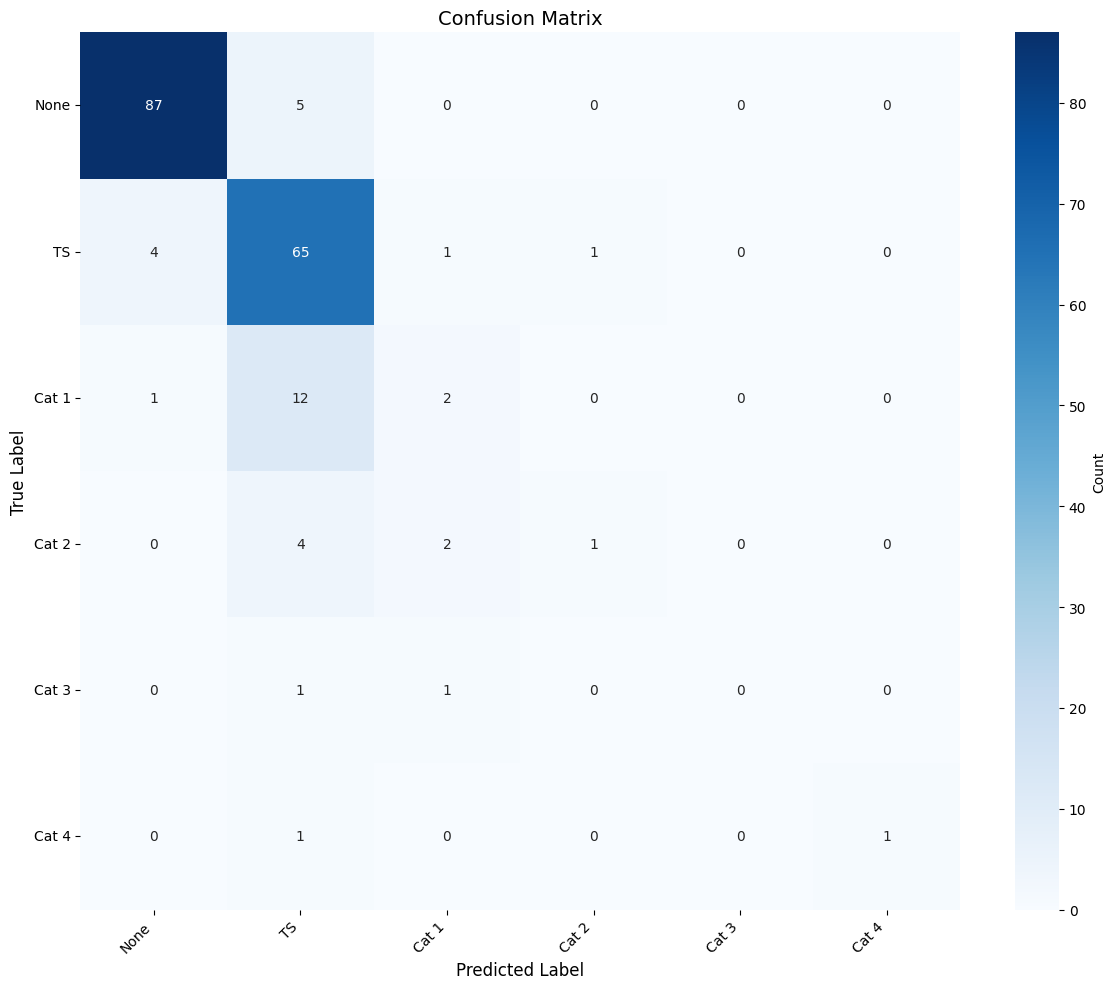


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        None     0.9457    0.9457    0.9457        92
          TS     0.7386    0.9155    0.8176        71
       Cat 1     0.3333    0.1333    0.1905        15
       Cat 2     0.5000    0.1429    0.2222         7
       Cat 3     0.0000    0.0000    0.0000         2
       Cat 4     1.0000    0.5000    0.6667         2

    accuracy                         0.8254       189
   macro avg     0.5863    0.4396    0.4738       189
weighted avg     0.7934    0.8254    0.7979       189


PER-CLASS BREAKDOWN
None                      | True:   92 | Predicted:   92 | Correct:   87 | Acc: 94.57%
TS                        | True:   71 | Predicted:   88 | Correct:   65 | Acc: 91.55%
Cat 1                     | True:   15 | Predicted:    6 | Correct:    2 | Acc: 13.33%
Cat 2                     | True:    7 | Predicted:    2 | Correct:    1 | Acc: 14.29%
Cat 3                     | True:    2 | Predicted:    0 | Correc

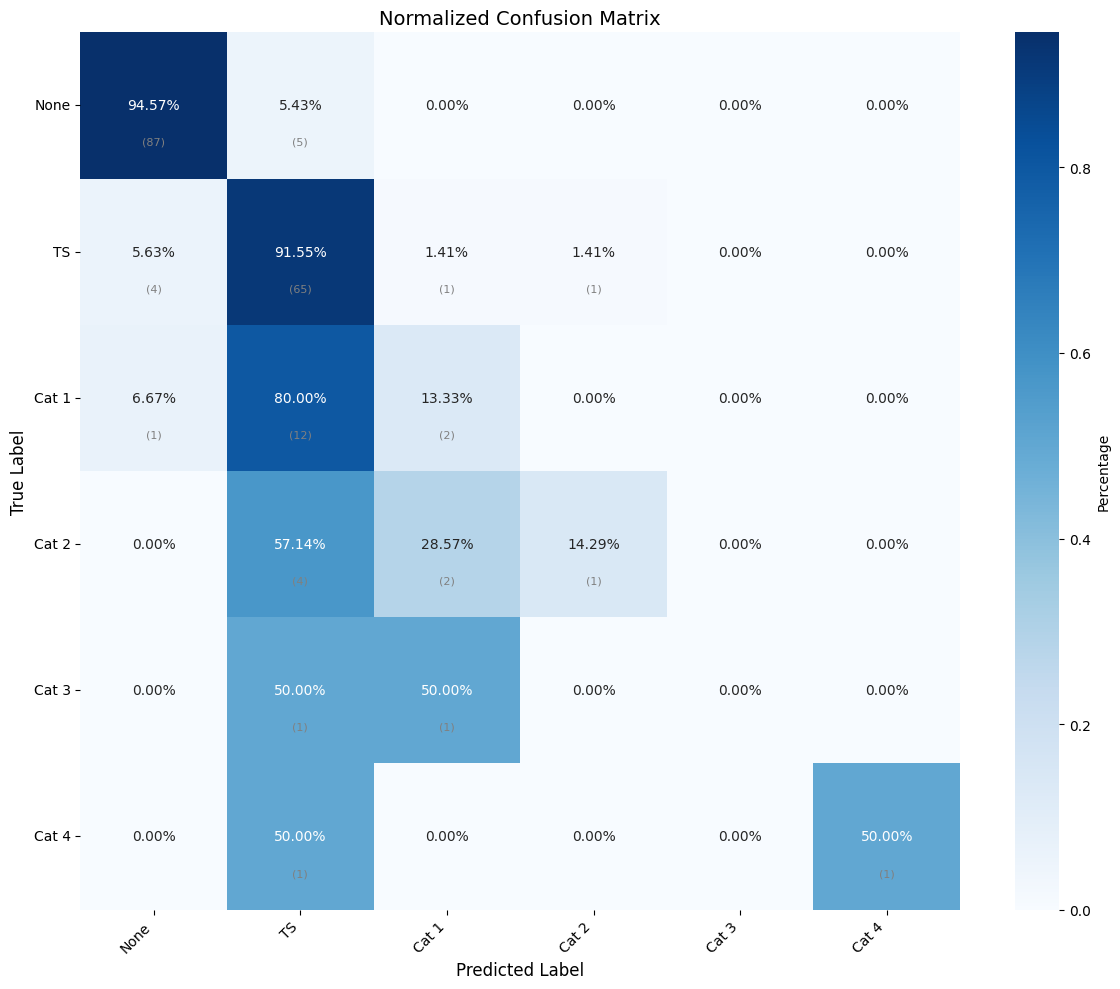


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        None     0.9457    0.9457    0.9457        92
          TS     0.7386    0.9155    0.8176        71
       Cat 1     0.3333    0.1333    0.1905        15
       Cat 2     0.5000    0.1429    0.2222         7
       Cat 3     0.0000    0.0000    0.0000         2
       Cat 4     1.0000    0.5000    0.6667         2

    accuracy                         0.8254       189
   macro avg     0.5863    0.4396    0.4738       189
weighted avg     0.7934    0.8254    0.7979       189


PER-CLASS BREAKDOWN
None                      | True:   92 | Predicted:   92 | Correct:   87 | Acc: 94.57%
TS                        | True:   71 | Predicted:   88 | Correct:   65 | Acc: 91.55%
Cat 1                     | True:   15 | Predicted:    6 | Correct:    2 | Acc: 13.33%
Cat 2                     | True:    7 | Predicted:    2 | Correct:    1 | Acc: 14.29%
Cat 3                     | True:    2 | Predicted:    0 | Correc

array([[87,  5,  0,  0,  0,  0],
       [ 4, 65,  1,  1,  0,  0],
       [ 1, 12,  2,  0,  0,  0],
       [ 0,  4,  2,  1,  0,  0],
       [ 0,  1,  1,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  1]])

In [7]:
cm = plot_confusion_matrix(all_predictions, normalize=False)
plot_confusion_matrix(all_predictions, normalize=True)

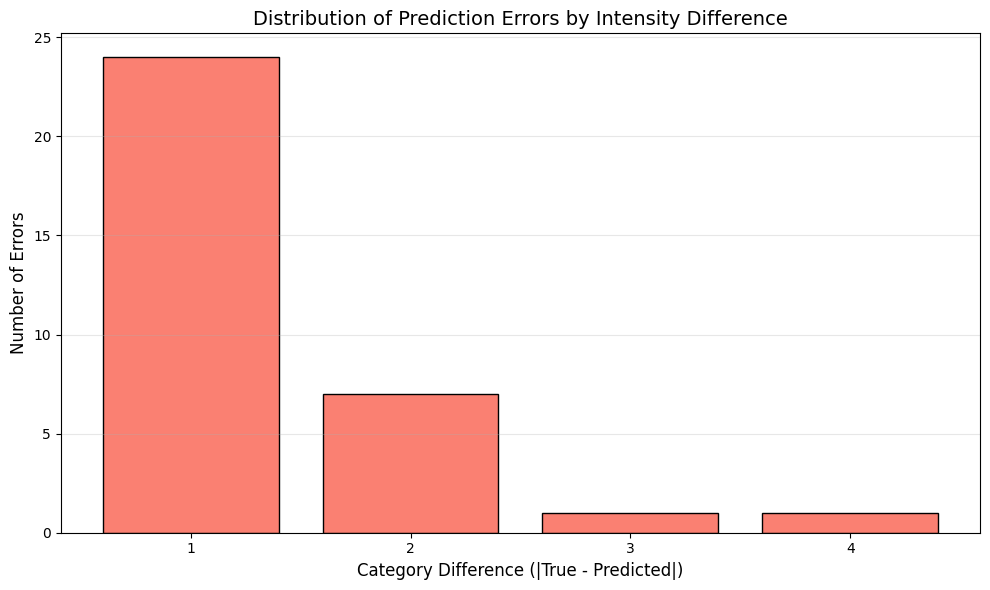


ERROR ANALYSIS
Off by 1 category:   24 (72.7%)
Off by 2 categories:    7 (21.2%)
Off by 3 categories:    1 (3.0%)
Off by 4 categories:    1 (3.0%)

WORST ERRORS (Most categories off)
1. True: Category 4                | Pred: Tropical Storm or Below   | Off by: 4 | Conf: 0.565
2. True: Category 3                | Pred: Tropical Storm or Below   | Off by: 3 | Conf: 0.586
3. True: Tropical Storm or Below   | Pred: Category 2                | Off by: 2 | Conf: 0.536
4. True: Category 2                | Pred: Tropical Storm or Below   | Off by: 2 | Conf: 0.494
5. True: Category 3                | Pred: Category 1                | Off by: 2 | Conf: 0.370
6. True: Category 1                | Pred: -9999                     | Off by: 2 | Conf: 0.641
7. True: Category 2                | Pred: Tropical Storm or Below   | Off by: 2 | Conf: 0.631
8. True: Category 2                | Pred: Tropical Storm or Below   | Off by: 2 | Conf: 0.484
9. True: Category 2                | Pred: Tropical Stor

In [8]:
# 2. Analyze intensity errors
analyze_intensity_errors(all_predictions)


-9999: 87 correct predictions


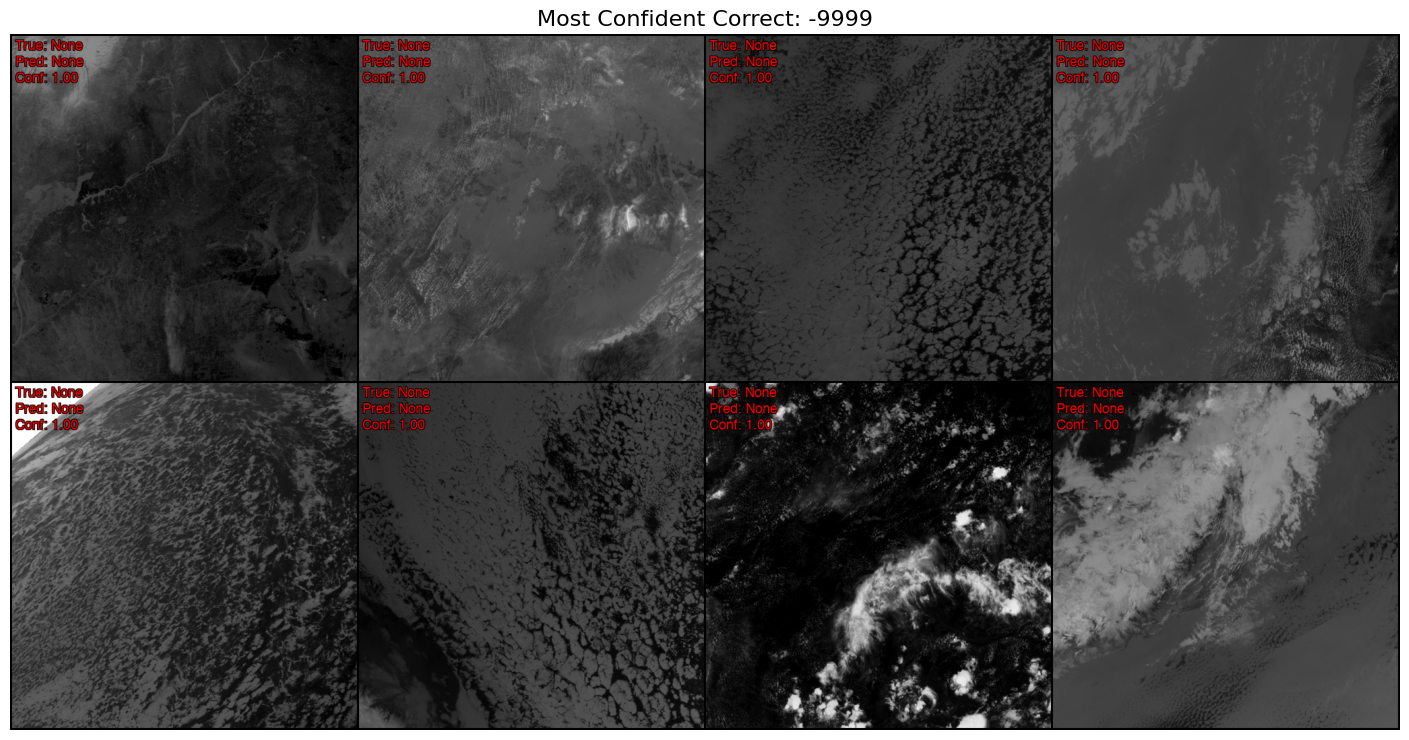


Tropical Storm or Below: 65 correct predictions


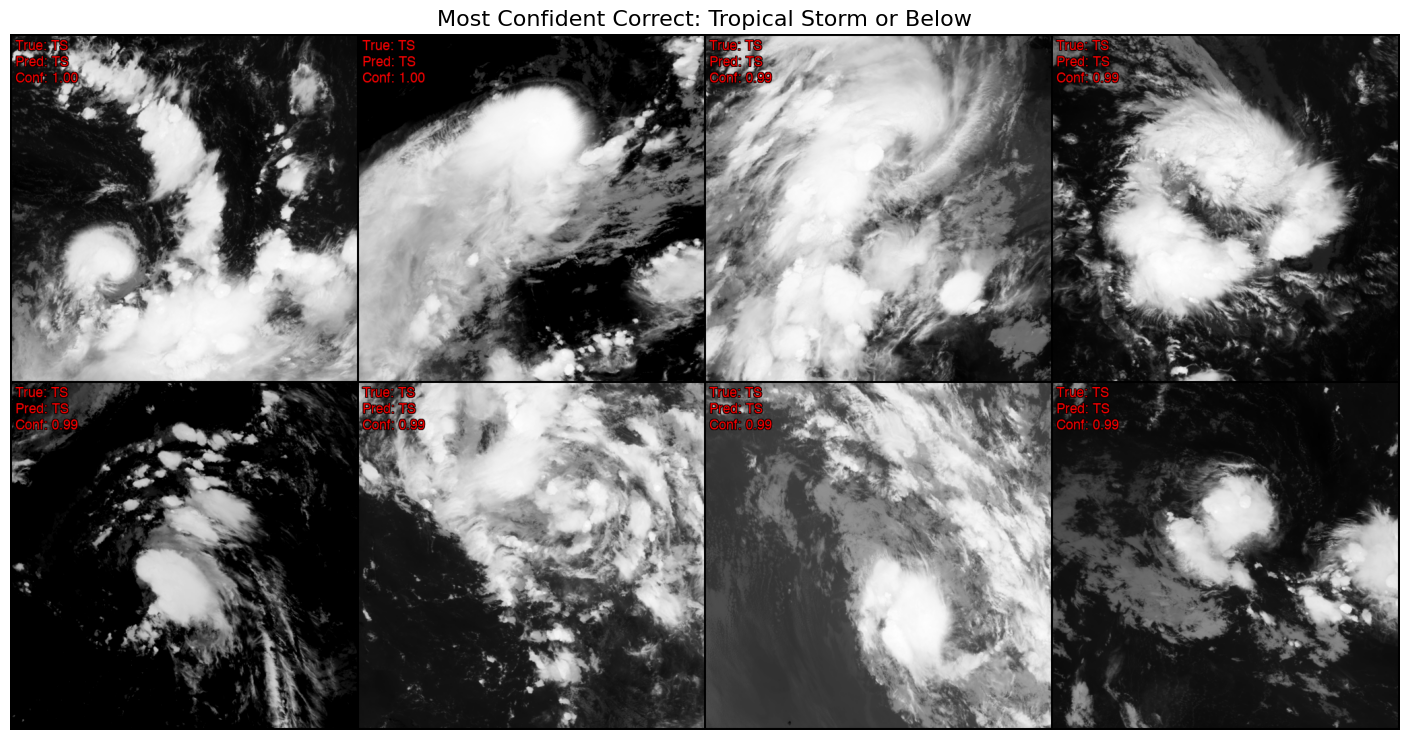


Category 1: 2 correct predictions


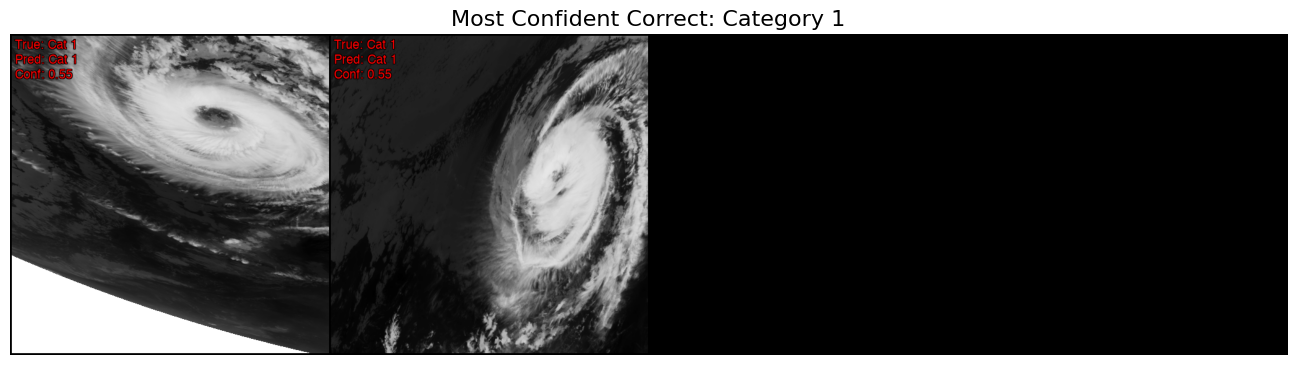


Category 2: 1 correct predictions


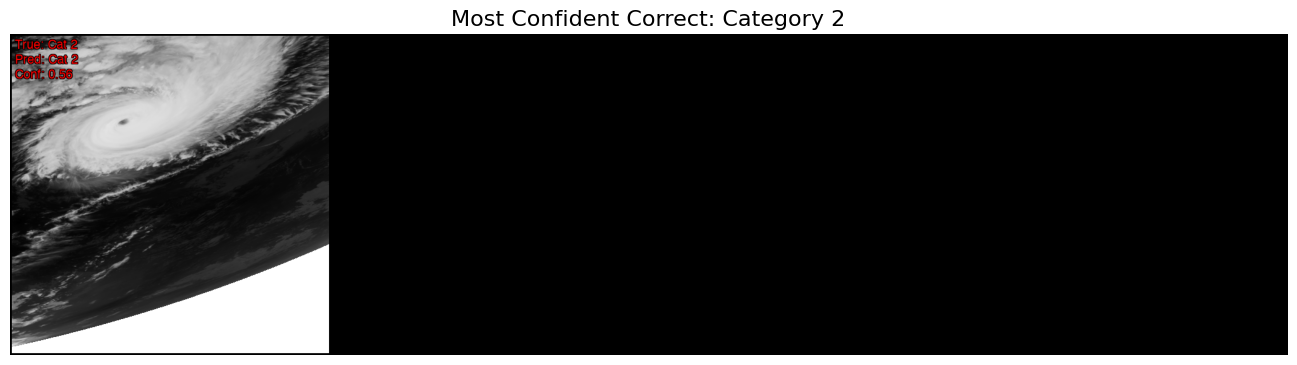


Category 3: 0 correct predictions

Category 4: 1 correct predictions


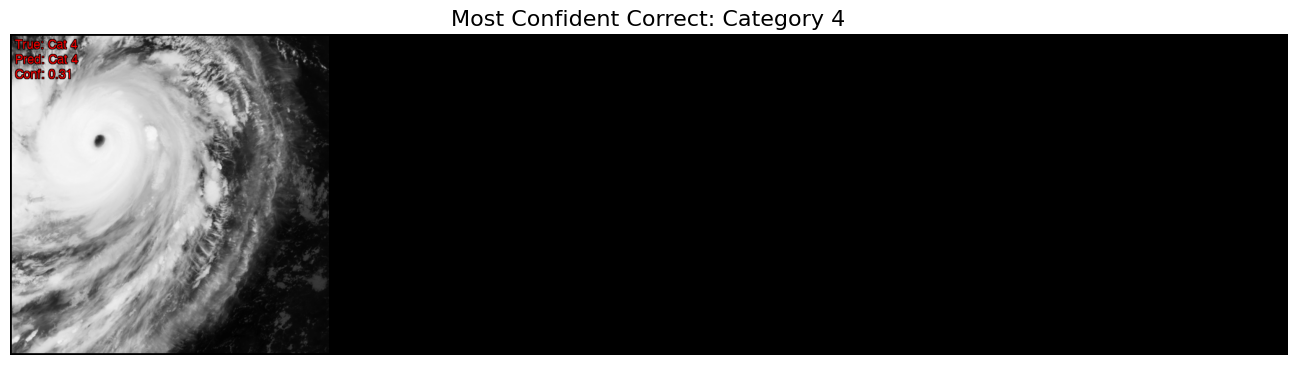


Category 5: 0 correct predictions


In [12]:
for class_idx in range(7):
    class_name = LABEL_NAMES[class_idx]
    correct_preds = filter_by_class(all_predictions, true_class=class_idx, correct_only=True)
    print(f"\n{class_name}: {len(correct_preds)} correct predictions")
    if len(correct_preds) > 0:
        visualize_predictions(correct_preds, num_images=8, 
                            title=f"Most Confident Correct: {class_name}")

Total mistakes: 33


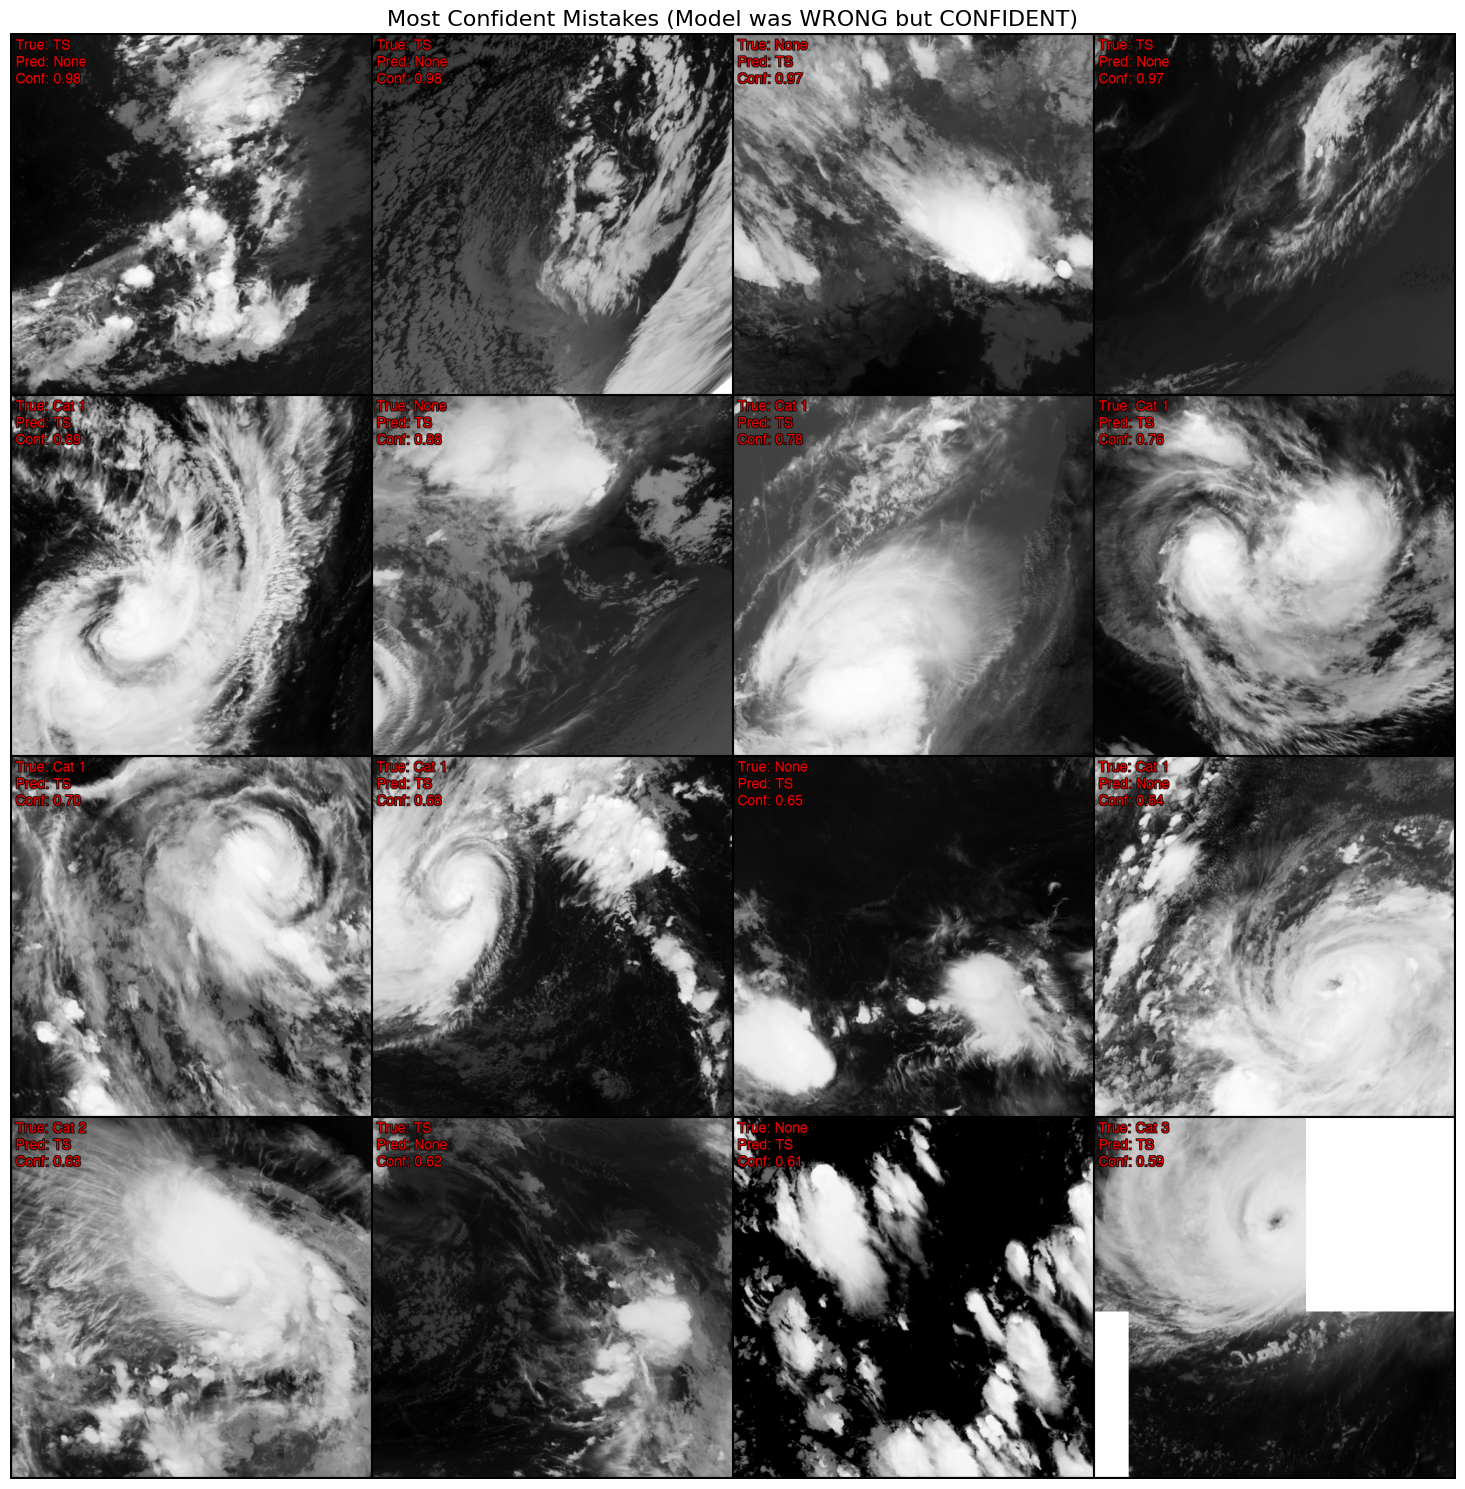

In [13]:
incorrect_preds = filter_by_class(all_predictions, incorrect_only=True)
print(f"Total mistakes: {len(incorrect_preds)}")
visualize_predictions(incorrect_preds, num_images=16, 
                        title="Most Confident Mistakes (Model was WRONG but CONFIDENT)")

In [14]:
missed_cat5 = filter_by_class(all_predictions, true_class=6, incorrect_only=True)
print(f"Category 5 storms misclassified: {len(missed_cat5)}")
if len(missed_cat5) > 0:
    visualize_predictions(missed_cat5, num_images=8, 
                            title="Missed Category 5 Storms (Most Confident)")

Category 5 storms misclassified: 0


In [15]:
false_alarms = [p for p in all_predictions 
                if p['pred_label'] >= 5 and p['true_label'] <= 1]
false_alarms.sort(key=lambda x: x['confidence'], reverse=True)
print(f"False high-intensity alarms: {len(false_alarms)}")
if len(false_alarms) > 0:
    visualize_predictions(false_alarms, num_images=8,
                            title="False Alarms: Predicted Cat 4-5, Actually Weak/None")

False high-intensity alarms: 0
